In [ ]:
# Environment Setup and Imports


# Suppress TensorFlow/CUDA warnings (must be before importing TensorFlow)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF logging (0=all, 1=info, 2=warning, 3=error)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN warnings

# Suppress CUDA registration warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Audio processing
import librosa
import librosa.display

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import register_keras_serializable

# Suppress additional TF warnings after import
tf.get_logger().setLevel('ERROR')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available: {gpus[0].name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU config error: {e}")
else:
    print("No GPU detected - using CPU")

print("=" * 60)
print("✓ Setup complete!")

GPU Available: /physical_device:GPU:0
GPU memory growth enabled
✓ Setup complete!


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashdogra/speech-commands")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'speech-commands' dataset.
Path to dataset files: /kaggle/input/speech-commands


In [ ]:
if os.path.exists(path):
    contents = os.listdir(path)
    print(f"✓ Dataset found at: {path}")
    print(f"  Total folders: {len(contents)}")
    print(f"  Sample folders: {contents[:5]}...")
else:
    print(f"✗ Dataset NOT found at: {path}")
    print("  Please check your Kaggle dataset path")


COMMANDS = [
    'yes', 'no', 'up', 'down', 'left', 'right',
    'on', 'off', 'stop', 'go'
]

# Audio parameters
SAMPLE_RATE = 16000      # 16kHz - standard for speech
AUDIO_LENGTH = 16000     # 1 second of audio (16000 samples at 16kHz)
N_MELS = 128             # Number of Mel frequency bands
N_FFT = 2048             # FFT window size
HOP_LENGTH = 160         # Hop length between FFT windows


MAX_SAMPLES = None



✓ Dataset found at: /kaggle/input/speech-commands
  Total folders: 40
  Sample folders: ['no', 'two', 'backward', 'four', 'five']...


In [ ]:
import glob
def load_audio(file_path, target_sr=SAMPLE_RATE):
    audio, sr = librosa.load(file_path, sr=target_sr)
    return audio, sr


def pad_or_trim(audio, target_length=AUDIO_LENGTH):
    if len(audio) < target_length:
        # Pad with zeros at the end
        padding = target_length - len(audio)
        audio = np.pad(audio, (0, padding), mode='constant')
    else:
        # Trim to target length
        audio = audio[:target_length]
    return audio


def normalize_audio(audio):
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio


def preprocess_audio(file_path, target_sr=SAMPLE_RATE, target_length=AUDIO_LENGTH):
    audio, sr = load_audio(file_path, target_sr)
    audio = pad_or_trim(audio, target_length)
    audio = normalize_audio(audio)
    return audio

NOISE_PATH = os.path.join(path, '_background_noise_')
NOISE_AUGMENT_PROB = 0.5   # 50% of training samples get noise mixed in
NOISE_SNR_DB = 10           # signal-to-noise ratio — higher = quieter noise

# ── 1. Load all noise files ───────────────────────────────────
def load_noise_files(noise_path, target_sr=SAMPLE_RATE):
    noise_clips = []
    for f in glob.glob(os.path.join(noise_path, '*.wav')):
        audio, _ = librosa.load(f, sr=target_sr)
        noise_clips.append(audio)
    print(f"Loaded {len(noise_clips)} noise files")
    return noise_clips

noise_clips = load_noise_files(NOISE_PATH)

# ── 2. Slice noise into 1-second chunks → silence class ───────
def create_noise_samples(noise_clips, target_length=AUDIO_LENGTH, n_samples=1000):
    """Cut random 1-second windows from noise files to form a silence class."""
    samples = []
    for _ in range(n_samples):
        clip = noise_clips[np.random.randint(len(noise_clips))]
        if len(clip) < target_length:
            clip = np.pad(clip, (0, target_length - len(clip)))
        start = np.random.randint(0, len(clip) - target_length)
        samples.append(clip[start:start + target_length])
    return samples

noise_samples = create_noise_samples(noise_clips, n_samples=1500)

# Add to your dataset as '_background_noise_' class
# (add '_background_noise_' to your COMMANDS list and include these samples in X, y)

# ── 3. Noise mixing augmentation ──────────────────────────────
def mix_noise(audio, noise_clips, snr_db=NOISE_SNR_DB):
    """Mix a random noise clip into audio at a given SNR."""
    noise = noise_clips[np.random.randint(len(noise_clips))]

    # Grab a random window of the noise clip
    if len(noise) < len(audio):
        noise = np.pad(noise, (0, len(audio) - len(noise)))
    start = np.random.randint(0, len(noise) - len(audio) + 1)
    noise = noise[start:start + len(audio)]

    # Scale noise to desired SNR
    signal_power = np.mean(audio ** 2) + 1e-9
    noise_power  = np.mean(noise  ** 2) + 1e-9
    scale = np.sqrt(signal_power / (noise_power * (10 ** (snr_db / 10))))
    return normalize_audio(audio + scale * noise)

def extract_mel_spectrogram(audio, sr=SAMPLE_RATE, n_mels=N_MELS,
                            n_fft=N_FFT, hop_length=HOP_LENGTH):
    # Compute Mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )
    # Convert to dB scale (log scale, better for neural networks)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

print(f"  Expected spectrogram shape: ({N_MELS}, {AUDIO_LENGTH // HOP_LENGTH + 1})")

Loaded 6 noise files
  Expected spectrogram shape: (128, 101)


In [ ]:
class SpecAugment:

    def __init__(self, freq_mask_param=15, time_mask_param=20,
                 num_freq_masks=1, num_time_masks=1):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def frequency_mask(self, spec):
        num_mels = spec.shape[0]
        for _ in range(self.num_freq_masks):
            f = np.random.randint(0, self.freq_mask_param + 1)
            f = min(f, num_mels)
            f0 = np.random.randint(0, max(1, num_mels - f))
            spec[f0:f0 + f, :] = spec.mean()
        return spec

    def time_mask(self, spec):
        num_frames = spec.shape[1]
        for _ in range(self.num_time_masks):
            t = np.random.randint(0, self.time_mask_param + 1)
            t = min(t, num_frames)
            t0 = np.random.randint(0, max(1, num_frames - t))
            spec[:, t0:t0 + t] = spec.mean()
        return spec

    def __call__(self, spec, augment_prob=0.5):
        if np.random.random() > augment_prob:
            return spec
        spec = spec.copy()
        spec = self.frequency_mask(spec)
        spec = self.time_mask(spec)
        return spec


# Initialize SpecAugment with balanced parameters
spec_augment = SpecAugment(
    freq_mask_param=15,   # Max frequency mask width
    time_mask_param=20,   # Max time mask width
    num_freq_masks=1,     # Number of frequency masks
    num_time_masks=1      # Number of time masks
)

print(f"  Frequency mask: up to {spec_augment.freq_mask_param} bands")
print(f"  Time mask: up to {spec_augment.time_mask_param} frames")

  Frequency mask: up to 15 bands
  Time mask: up to 20 frames


In [ ]:
def create_dataset(dataset_path, commands, noise_samples=None, max_samples_per_class=None, verbose=True):
    X_raw = []
    X = []
    y = []

    print("LOADING DATASET")

    for command in commands:
        command_path = os.path.join(dataset_path, command)

        if not os.path.exists(command_path):
            print(f"⚠️  Warning: Folder not found for '{command}'")
            continue

        files = [f for f in os.listdir(command_path) if f.endswith('.wav')]
        if max_samples_per_class:
            files = files[:max_samples_per_class]
        if verbose:
            print(f"  Processing '{command}': {len(files)} files")

        for file_name in files:
            file_path = os.path.join(command_path, file_name)
            try:
                audio = preprocess_audio(file_path)
                features = extract_mel_spectrogram(audio)
                X_raw.append(audio)
                X.append(features)
                y.append(command)
            except Exception:
                continue

    # Add noise samples as background noise class
    if noise_samples is not None:
        print(f"  Processing '_background_noise_': {len(noise_samples)} samples")
        for audio in noise_samples:
            audio = normalize_audio(audio)
            features = extract_mel_spectrogram(audio)
            X_raw.append(audio)
            X.append(features)
            y.append('_background_noise_')

    X_raw = np.array(X_raw)
    X = np.array(X)
    y = np.array(y)

    print("=" * 60)
    print(f"✓ Dataset created successfully!")
    print(f"  Total samples: {len(X)}")
    print(f"  Feature shape: {X.shape}")
    print(f"  Classes: {len(np.unique(y))}")
    print("=" * 60)

    return X_raw, X, y


# Create dataset
NOISE_PATH = os.path.join(path, '_background_noise_')
noise_clips = load_noise_files(NOISE_PATH)
noise_samples = create_noise_samples(noise_clips, n_samples=1500)
X_raw, X, y = create_dataset(
    path,
    COMMANDS,
    noise_samples=noise_samples,
    max_samples_per_class=MAX_SAMPLES
)

Loaded 6 noise files
LOADING DATASET
  Processing 'yes': 4044 files
  Processing 'no': 3941 files
  Processing 'up': 3723 files
  Processing 'down': 3917 files
  Processing 'left': 3801 files
  Processing 'right': 3778 files
  Processing 'on': 3845 files
  Processing 'off': 3745 files
  Processing 'stop': 3872 files
  Processing 'go': 3880 files
  Processing '_background_noise_': 1500 samples
✓ Dataset created successfully!
  Total samples: 40046
  Feature shape: (40046, 128, 101)
  Classes: 11


In [ ]:
print("PREPARING DATA")

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: '{label}'")

# Split spectrograms and raw waveforms together using same random_state
X_train, X_test, X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X, X_raw, y_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, X_raw_train, X_raw_val, y_train, y_val = train_test_split(
    X_train, X_raw_train, y_train,
    test_size=0.12,
    random_state=42,
    stratify=y_train
)

print(f"\nDataset split:")
print(f"  Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Add channel dim to spectrograms: (N, H, W) → (N, H, W, 1)
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"\nInput shape for CNN: {X_train.shape[1:]}")

# Normalize using training statistics only (prevent data leakage)
# X_raw stays unnormalized — normalization happens per-sample in the generator
X_mean = np.mean(X_train)
X_std  = np.std(X_train)

X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

print(f"Normalization stats: mean={X_mean:.4f}, std={X_std:.4f}")
print(f"Raw waveform splits: train={X_raw_train.shape}, val={X_raw_val.shape}, test={X_raw_test.shape}")

PREPARING DATA
Label encoding:
  0: '_background_noise_'
  1: 'down'
  2: 'go'
  3: 'left'
  4: 'no'
  5: 'off'
  6: 'on'
  7: 'right'
  8: 'stop'
  9: 'up'
  10: 'yes'

Dataset split:
  Training:   29,954 samples (74.8%)
  Validation: 4,085 samples (10.2%)
  Test:       6,007 samples (15.0%)

Input shape for CNN: (128, 101, 1)
Normalization stats: mean=-56.7068, std=20.3224
Raw waveform splits: train=(29954, 16000), val=(4085, 16000), test=(6007, 16000)


In [ ]:
@register_keras_serializable(package="CustomSchedules")
class CosineDecayWithWarmup(keras.optimizers.schedules.LearningRateSchedule):
    """
    Cosine decay learning rate schedule with linear warmup.
    """

    def __init__(self, initial_learning_rate=1e-3, decay_steps=10000,
                 warmup_steps=1000, min_learning_rate=1e-6):
        super().__init__()
        self.initial_learning_rate = initial_learning_rate
        self.decay_steps = decay_steps
        self.warmup_steps = warmup_steps
        self.min_learning_rate = min_learning_rate

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps_f = tf.cast(self.warmup_steps, tf.float32)
        decay_steps_f = tf.cast(self.decay_steps, tf.float32)

        # Linear warmup
        warmup_lr = self.initial_learning_rate * (step / tf.maximum(warmup_steps_f, 1.0))

        # Cosine decay
        decay_step = step - warmup_steps_f
        total_decay_steps = tf.maximum(decay_steps_f - warmup_steps_f, 1.0)
        cosine_decay = 0.5 * (1.0 + tf.cos(np.pi * decay_step / total_decay_steps))
        decayed_lr = self.min_learning_rate + \
                     (self.initial_learning_rate - self.min_learning_rate) * cosine_decay

        # Use warmup LR if in warmup phase, else use decayed LR
        return tf.where(step < warmup_steps_f, warmup_lr, decayed_lr)

    def get_config(self):
        return {
            'initial_learning_rate': float(self.initial_learning_rate),
            'decay_steps': int(self.decay_steps),
            'warmup_steps': int(self.warmup_steps),
            'min_learning_rate': float(self.min_learning_rate)
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)


print("✓ CosineDecayWithWarmup learning rate schedule defined")

✓ CosineDecayWithWarmup learning rate schedule defined


In [ ]:
class SpecAugmentDataGenerator(keras.utils.Sequence):
    def __init__(self, X_raw, y, batch_size=32, shuffle=True, augment=True,
                 spec_augment=None, noise_clips=None, noise_prob=0.5,
                 normalize_mean=0, normalize_std=1, augment_prob=0.5):
        self.X_raw = X_raw          # raw waveforms [N, AUDIO_LENGTH]
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.spec_augment = spec_augment or SpecAugment()
        self.noise_clips = noise_clips
        self.noise_prob = noise_prob
        self.mean = normalize_mean
        self.std  = normalize_std
        self.augment_prob = augment_prob
        self.indices = np.arange(len(X_raw))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X_raw) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X = []

        for i in batch_idx:
            audio = self.X_raw[i].copy()

            # Mix in background noise before computing spectrogram
            if self.augment and self.noise_clips and np.random.random() < self.noise_prob:
                audio = mix_noise(audio, self.noise_clips)

            # Compute mel spectrogram
            spec = extract_mel_spectrogram(audio)

            # Apply SpecAugment
            if self.augment:
                spec = self.spec_augment(spec, augment_prob=self.augment_prob)

            # Normalize + add channel dim
            spec = (spec - self.mean) / self.std
            batch_X.append(spec[..., np.newaxis])

        return np.array(batch_X), self.y[batch_idx]

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)




train_generator = SpecAugmentDataGenerator(
    X_raw_train, y_train,
    batch_size=32,
    shuffle=True,
    augment=True,
    spec_augment=spec_augment,
    noise_clips=noise_clips,
    noise_prob=0.5,
    normalize_mean=X_mean,
    normalize_std=X_std,
    augment_prob=0.5
)

val_generator = SpecAugmentDataGenerator(
    X_raw_val, y_val,
    batch_size=32,
    shuffle=False,
    augment=False,
    normalize_mean=X_mean,
    normalize_std=X_std
)

print("✓ Data generators created")
print(f"  Training batches: {len(train_generator)}")
print(f"  Validation batches: {len(val_generator)}")
print(f"  Batch size: 32")

✓ Data generators created
  Training batches: 937
  Validation batches: 128
  Batch size: 32


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
def se_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(channels // ratio, 4), activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

def res_block(x, filters, stride=1, dropout=0.0):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if dropout > 0:
        x = layers.SpatialDropout2D(dropout)(x)

    # Project shortcut if shape changed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def patch_transformer(x, dim=256, depth=4, heads=4, mlp_dim=512, dropout=0.1):
    # Patch embedding via 2x2 conv
    x = layers.Conv2D(dim, kernel_size=2, strides=2, padding='same',
                      kernel_initializer='he_normal')(x)   # [B, H/2, W/2, dim]

    # Flatten spatial dims — use Flatten then reshape via a layer, not tf.shape
    new_seq_len = (x.shape[1] or 1) * (x.shape[2] or 1)  # static shape only
    x = layers.Reshape((new_seq_len, dim))(x)              # [B, N_patches, dim]
    x = layers.LayerNormalization()(x)

    # Transformer encoder blocks
    for _ in range(depth):
        # Pre-LN Multi-head Self-Attention
        residual = x
        x = layers.LayerNormalization()(x)
        x = layers.MultiHeadAttention(
            num_heads=heads, key_dim=dim // heads, dropout=dropout
        )(x, x)
        x = layers.Dropout(dropout)(x)
        x = layers.Add()([x, residual])

        # Pre-LN Feed-forward
        residual = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(mlp_dim, activation='relu',
                         kernel_initializer='he_normal')(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(dim, kernel_initializer='he_normal')(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Add()([x, residual])

    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    return x

def create_model(input_shape, num_classes, dropout=0.2):

    inputs = layers.Input(shape=input_shape)

    # ── Stem ──────────────────────────────────
    x = layers.Conv2D(64, 7, strides=2, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # ── Stage 1: 64 filters ───────────────────
    x = res_block(x,  64, stride=1, dropout=0.0)
    x = res_block(x,  64, dropout=0.0)
    x = layers.SpatialDropout2D(0.10)(x)

    # ── Stage 2: 128 filters ──────────────────
    x = res_block(x, 128, stride=2, dropout=0.0)
    x = res_block(x, 128, dropout=0.0)
    x = layers.SpatialDropout2D(0.20)(x)

    # ── Stage 3: 256 filters + SE ─────────────
    x = res_block(x, 256, stride=2, dropout=0.0)
    x = res_block(x, 256, dropout=0.0)
    x = se_block(x)
    x = layers.SpatialDropout2D(0.25)(x)

    # ── Stage 4: 512 filters + SE ─────────────
    x = res_block(x, 512, stride=2, dropout=0.0)
    x = res_block(x, 512, dropout=0.0)
    x = se_block(x)
    x = layers.SpatialDropout2D(0.30)(x)

    # ── Patch Transformer ─────────────────────
    x = patch_transformer(x, dim=256, depth=4, heads=4,
                          mlp_dim=512, dropout=dropout)

    # ── Classifier head (matches example) ─────
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)          # aggressive dropout before final layers
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='CNN_Transformer_Audio')






In [ ]:
input_shape = X_train.shape[1:]   # (N_MELS, T, 1)
model = create_model(input_shape, num_classes, dropout=0.2)

TRAINING CONFIGURATION
  Epochs: 100
  Batch size: 32
  Steps per epoch: 937
  Total steps: 93,700
  Warmup steps: 4685 (5 epochs)
  Initial LR: 0.001
  Min LR: 1e-06


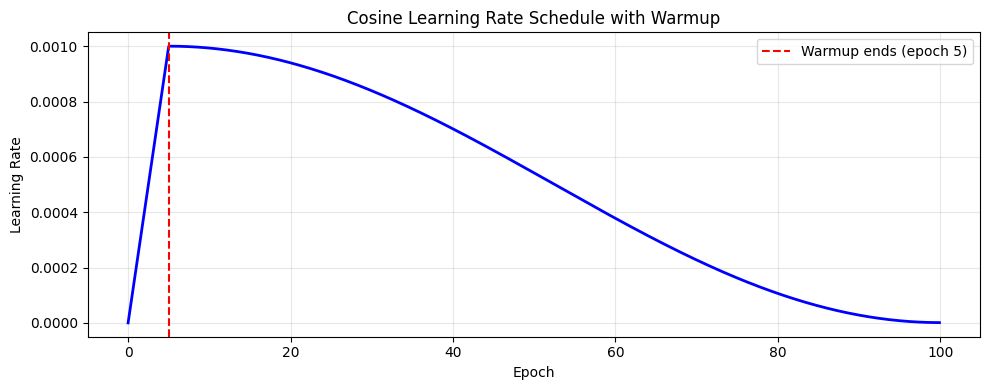


✓ Model compiled with Adam optimizer and cosine LR schedule


In [ ]:
# Training hyperparameters
EPOCHS = 100
BATCH_SIZE = 32
INITIAL_LR = 1e-3
MIN_LR = 1e-6
WARMUP_EPOCHS = 5

# Calculate training steps
steps_per_epoch = len(train_generator)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total steps: {total_steps:,}")
print(f"  Warmup steps: {warmup_steps} ({WARMUP_EPOCHS} epochs)")
print(f"  Initial LR: {INITIAL_LR}")
print(f"  Min LR: {MIN_LR}")

# Create learning rate schedule
lr_schedule = CosineDecayWithWarmup(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_steps,
    warmup_steps=warmup_steps,
    min_learning_rate=MIN_LR
)

# Visualize learning rate schedule
steps = np.arange(0, total_steps, 100)
lrs = [float(lr_schedule(step)) for step in steps]

plt.figure(figsize=(10, 4))
plt.plot(steps / steps_per_epoch, lrs, 'b-', linewidth=2)
plt.axvline(x=WARMUP_EPOCHS, color='r', linestyle='--', label=f'Warmup ends (epoch {WARMUP_EPOCHS})')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Cosine Learning Rate Schedule with Warmup')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compile model
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)  # your existing lr_schedule
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("\n✓ Model compiled with Adam optimizer and cosine LR schedule")
print("=" * 60)

In [ ]:
callback_list = [
    # Stop early if no improvement
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),

    # Save best model
    callbacks.ModelCheckpoint(
        filepath='best_model_resnet.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),

    # Log training history
    callbacks.CSVLogger('training_log.csv', append=False)
]

print("✓ Callbacks configured:")
print("  • EarlyStopping (patience=15)")
print("  • ModelCheckpoint (save best model)")
print("  • CSVLogger (training_log.csv)")

✓ Callbacks configured:
  • EarlyStopping (patience=15)
  • ModelCheckpoint (save best model)
  • CSVLogger (training_log.csv)


In [ ]:
print(f"Model: ResNet-style with SE attention and Transformer")
print(f"Augmentation: SpecAugment")
print(f"LR Schedule: Cosine decay with {WARMUP_EPOCHS}-epoch warmup")


# Train model (verbose=2 prevents IOPub rate limit error)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=2  # One line per epoch (prevents Kaggle output overflow)
)

print("✓ TRAINING COMPLETE!")


Model: ResNet-style with SE attention
Augmentation: SpecAugment
LR Schedule: Cosine decay with 5-epoch warmup
Epoch 1/100

Epoch 1: val_accuracy improved from None to 0.07466, saving model to best_model_resnet.keras

Epoch 1: finished saving model to best_model_resnet.keras
937/937 - 414s - 442ms/step - accuracy: 0.1382 - loss: 3.9775 - val_accuracy: 0.0747 - val_loss: 4.6894
Epoch 2/100

Epoch 2: val_accuracy improved from 0.07466 to 0.60832, saving model to best_model_resnet.keras

Epoch 2: finished saving model to best_model_resnet.keras
937/937 - 275s - 294ms/step - accuracy: 0.3551 - loss: 2.8306 - val_accuracy: 0.6083 - val_loss: 2.0841
Epoch 3/100

Epoch 3: val_accuracy improved from 0.60832 to 0.81273, saving model to best_model_resnet.keras

Epoch 3: finished saving model to best_model_resnet.keras
937/937 - 267s - 285ms/step - accuracy: 0.6483 - loss: 1.9945 - val_accuracy: 0.8127 - val_loss: 1.4650
Epoch 4/100

Epoch 4: val_accuracy improved from 0.81273 to 0.87001, saving m

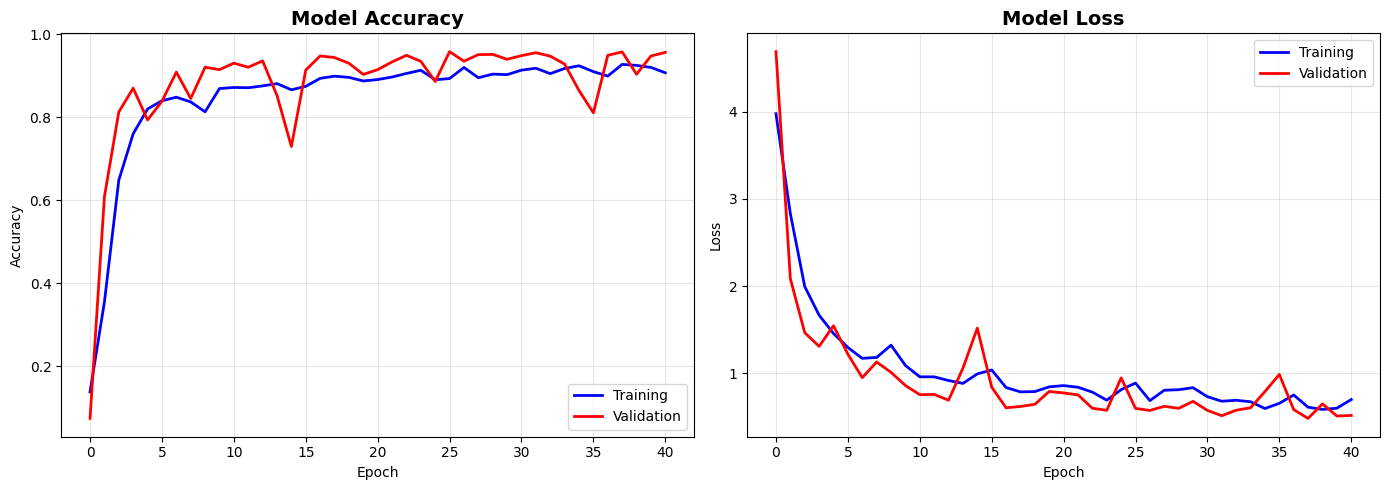

TRAINING SUMMARY
  Total epochs: 41
  Best validation accuracy: 0.9579 (epoch 26)
  Final training accuracy: 0.9071
  Final validation accuracy: 0.9562
📊 Training < Validation accuracy: This is EXPECTED with SpecAugment!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], 'b-', label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], 'b-', label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
best_val_acc = max(history.history['val_accuracy'])
best_epoch = np.argmax(history.history['val_accuracy']) + 1
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print("TRAINING SUMMARY")
print(f"  Total epochs: {len(history.history['accuracy'])}")
print(f"  Best validation accuracy: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"  Final training accuracy: {final_train_acc:.4f}")
print(f"  Final validation accuracy: {final_val_acc:.4f}")
if final_train_acc < final_val_acc:
    print("📊 Training < Validation accuracy: This is EXPECTED with SpecAugment!")


In [ ]:
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Model size: ~{model.count_params() * 4 / 1024 / 1024:.1f} MB")

# Load best model
custom_objects = {'CosineDecayWithWarmup': CosineDecayWithWarmup}
best_model = keras.models.load_model('best_model_resnet.keras',
                                      custom_objects=custom_objects)

# Build test spectrograms from raw waveforms
print("Preparing test spectrograms...")
X_test_specs = np.array([
    extract_mel_spectrogram(audio) for audio in X_raw_test
])
X_test_specs = (X_test_specs - X_mean) / X_std
X_test_specs = X_test_specs[..., np.newaxis]   # [N, N_MELS, T, 1]

# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_accuracy = best_model.evaluate(X_test_specs, y_test, verbose=0)

print()
print("=" * 60)
print("🎯 TEST RESULTS")
print("=" * 60)
print(f"  Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Test Loss:      {test_loss:.4f}")
print(f"  Num classes:    {num_classes} (includes _background_noise_)")
print("=" * 60)

# Generate predictions
y_pred_proba = best_model.predict(X_test_specs, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Classification report
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred,
                             target_names=label_encoder.classes_,
                             digits=4))

Model: "CNN_Transformer_Audio"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 101,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 51,    │      3,200 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 51,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 26,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 26,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 26,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 26,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 26,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 26,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 26,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 26,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 26,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 26,    │        256 │ conv2d_4[0][0]  

 Total params: 41,865,394 (159.70 MB)

 Trainable params: 13,951,675 (53.22 MB)

 Non-trainable params: 10,368 (40.50 KB)

 Optimizer params: 27,903,351 (106.44 MB)


Total parameters: 13,962,043
Model size: ~53.3 MB
Preparing test spectrograms...
Evaluating on test set...

🎯 TEST RESULTS
  Test Accuracy:  0.9607 (96.07%)
  Test Loss:      0.5796
  Num classes:    11 (includes _background_noise_)

Classification Report:
------------------------------------------------------------
                    precision    recall  f1-score   support

_background_noise_     0.8858    1.0000    0.9395       225
              down     0.9722    0.9523    0.9621       587
                go     0.9597    0.9416    0.9506       582
              left     0.9645    0.9544    0.9594       570
                no     0.9626    0.9577    0.9601       591
               off     0.9629    0.9235    0.9428       562
                on     0.9755    0.9653    0.9704       577
             right     0.9603    0.9806    0.9703       567
              stop     0.9843    0.9690    0.9766       581
                up     0.9297    0.9480    0.9388       558
               yes  

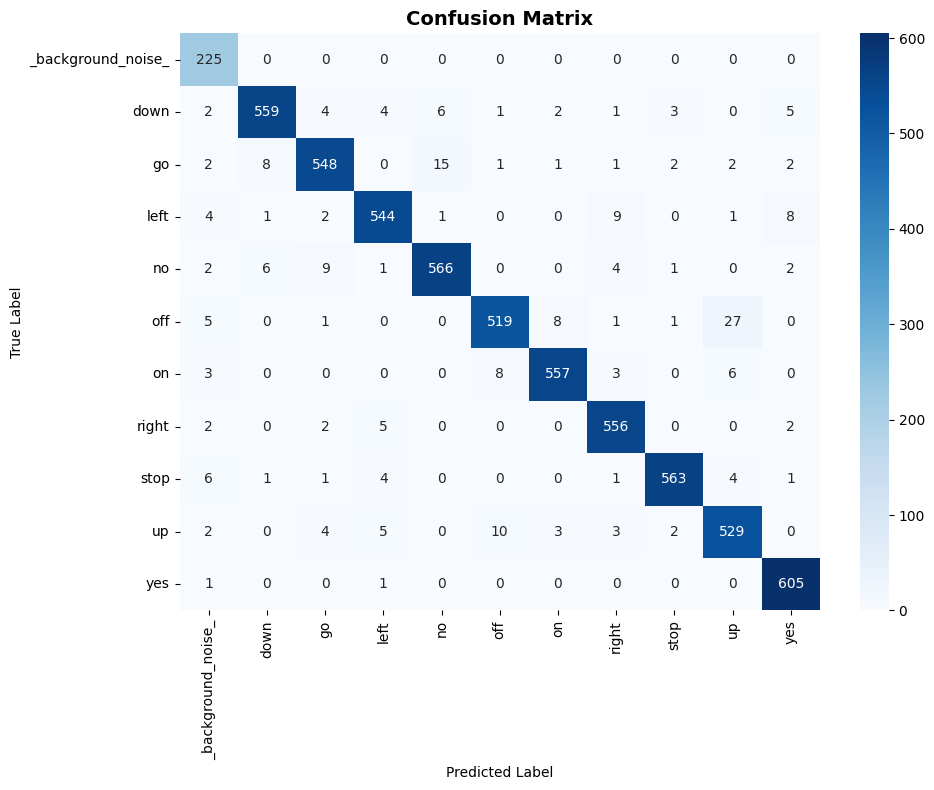

Per-Class Accuracy:
----------------------------------------
  _background_noise_: 1.0000 ██████████████████████████████
  yes     : 0.9967 █████████████████████████████
  right   : 0.9806 █████████████████████████████
  stop    : 0.9690 █████████████████████████████
  on      : 0.9653 ████████████████████████████
  no      : 0.9577 ████████████████████████████
  left    : 0.9544 ████████████████████████████
  down    : 0.9523 ████████████████████████████
  up      : 0.9480 ████████████████████████████
  go      : 0.9416 ████████████████████████████
  off     : 0.9235 ███████████████████████████


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("Per-Class Accuracy:")
print("-" * 40)
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for name, acc in sorted(zip(label_encoder.classes_, class_accuracy), key=lambda x: -x[1]):
    bar = '█' * int(acc * 30)
    print(f"  {name:8s}: {acc:.4f} {bar}")

In [ ]:
import json
import pickle

print("=" * 60)
print("SAVING MODEL AND ARTIFACTS")
print("=" * 60)

# Save final model
model.save('voice_command_model_final_noise.keras')
print("✓ Model saved: voice_command_model_final_noise.keras")

# Save label encoder
with open('label_encoder_noise.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✓ Label encoder saved: label_encoder_noise.pkl")

# Save configuration
config = {
    'model_name': 'CNN_Transformer_Audio',
    'commands': list(label_encoder.classes_),
    'num_classes': num_classes,
    'sample_rate': SAMPLE_RATE,
    'audio_length': AUDIO_LENGTH,
    'n_mels': N_MELS,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'feature_mean': float(X_mean),
    'feature_std': float(X_std),
    'test_accuracy': float(test_accuracy),
    'best_val_accuracy': float(best_val_acc),
    'training_epochs': len(history.history['accuracy']),
    # Noise augmentation settings
    'noise_augmentation': True,
    'noise_prob': NOISE_AUGMENT_PROB,
    'noise_snr_db': NOISE_SNR_DB,
    'noise_class_samples': len(noise_samples),
}

with open('model_config_noise.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✓ Config saved: model_config_noise.json")

# Print config
print("\nModel Configuration:")
print(json.dumps(config, indent=2))

print(f"\nFinal Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\nFiles saved:")
print("  • best_model_resnet.keras (best checkpoint)")
print("  • voice_command_model_final_noise.keras (final model)")
print("  • label_encoder_noise.pkl (label mapping)")
print("  • model_config_noise.json (configuration)")
print("  • training_log.csv (training history)")

SAVING MODEL AND ARTIFACTS
✓ Model saved: voice_command_model_final_noise.keras
✓ Label encoder saved: label_encoder_noise.pkl
✓ Config saved: model_config_noise.json

Model Configuration:
{
  "model_name": "CNN_Transformer_Audio",
  "commands": [
    "_background_noise_",
    "down",
    "go",
    "left",
    "no",
    "off",
    "on",
    "right",
    "stop",
    "up",
    "yes"
  ],
  "num_classes": 11,
  "sample_rate": 16000,
  "audio_length": 16000,
  "n_mels": 128,
  "n_fft": 2048,
  "hop_length": 160,
  "feature_mean": -56.70683670043945,
  "feature_std": 20.322399139404297,
  "test_accuracy": 0.9607124924659729,
  "best_val_accuracy": 0.9578947424888611,
  "training_epochs": 41,
  "noise_augmentation": true,
  "noise_prob": 0.5,
  "noise_snr_db": 10,
  "noise_class_samples": 1500
}

Final Test Accuracy: 0.9607 (96.07%)

Files saved:
  • best_model_resnet.keras (best checkpoint)
  • voice_command_model_final_noise.keras (final model)
  • label_encoder_noise.pkl (label mapping)
 